In [1]:
import numpy as np
from collections import Counter

## Ejercicio 1

b)

In [2]:
def calcular_entropia(probabilidades):
    entropia = 0.0
    for proba in probabilidades:
        if proba > 0:
            entropia -= proba * np.log2(proba)
    return entropia # en bits/símbolo

c)

In [3]:
# P(S1) = 0.50, P(S2) = 0.25, P(S3) = P(S4) = 0.125
probabilidades_ej1 = [0.50, 0.25, 0.125, 0.125]

entropia = calcular_entropia(probabilidades_ej1)

print(f"Distribución de probabilidad: {probabilidades_ej1}")
print(f"La entropía H(S): {entropia} [bits/símbolo]")

Distribución de probabilidad: [0.5, 0.25, 0.125, 0.125]
La entropía H(S): 1.75 [bits/símbolo]


## Ejercicio 2

In [4]:
# codigo del ejercicio:
frecuencias_espanol = {
    'espacio': 0.145, 'e': 0.115, 'a': 0.105, 'o': 0.075, 's': 0.073,
    'n': 0.046, 'r': 0.045, 'i': 0.044, 'l': 0.040, 'd': 0.038,
    't': 0.035, 'u': 0.034, 'c': 0.030, 'm': 0.025, 'p': 0.020
}

prob_restante = 1.0 - sum(frecuencias_espanol.values())
prob_por_letra_rara = prob_restante / 13.0
print(f"Probabilidad restante para las 13 letras raras: {prob_restante:.6f}")
print(f"Probabilidad por letra rara: {prob_por_letra_rara:.6f}")
probabilidades_ej2 = list(frecuencias_espanol.values()) + [prob_por_letra_rara] * 13

Probabilidad restante para las 13 letras raras: 0.130000
Probabilidad por letra rara: 0.010000


a. calculamos la entropía H.

In [5]:
H = calcular_entropia(probabilidades_ej2)

print(f"entropía: {H} [bits/símbolo]")

entropía: 4.225630157929781 [bits/símbolo]


b. calculamos la H_max posible. esto sería para un alfabeto de 28 símbolos equiprobables (p = 1/28).

In [6]:
H_max = np.log2(28)

print(f"entropía máxima: {H_max} [bits/símbolo]")

entropía máxima: 4.807354922057604 [bits/símbolo]


c. calculamos el porcentaje de Redundancia del idioma español:

In [7]:
redundancia = (1 - (H / H_max)) * 100

print(f"redundancia: {redundancia:.2f}%")

redundancia: 12.10%


Hay simbolos que aparecen bastante mas, por lo que la prediccion esta "sesgada" hacia esas letras, lo que introduce redundancia.

## Ejercicio 3

a)

In [8]:
mensaje = "el veloz murcielago hindu comia feliz cardillo y kiwi"

tamano_msj = len(mensaje)
print(f"Cantidad total de caracteres: {tamano_msj}")

Cantidad total de caracteres: 53


b) frecuencia absoluta de cada carácter

In [9]:
frecuencias_absolutas = Counter(mensaje)

print("Frecuencia de cada carácter:")
for caracter, frecuencia in frecuencias_absolutas.items():
    print(f"'{caracter}': {frecuencia}")    

Frecuencia de cada carácter:
'e': 4
'l': 6
' ': 8
'v': 1
'o': 4
'z': 2
'm': 2
'u': 2
'r': 2
'c': 3
'i': 7
'a': 3
'g': 1
'h': 1
'n': 1
'd': 2
'f': 1
'y': 1
'k': 1
'w': 1


c) dividimos la frecuencia por la cantidad total de caracteres

In [10]:
probabilidades_ej3 = {}
for char, freq in frecuencias_absolutas.items():
    probabilidades_ej3[char] = freq / tamano_msj

print("Probabilidad de aparición de cada carácter:")
for caracter, probabilidad in probabilidades_ej3.items():
    print(f"'{caracter}': {probabilidad:.6f}")

Probabilidad de aparición de cada carácter:
'e': 0.075472
'l': 0.113208
' ': 0.150943
'v': 0.018868
'o': 0.075472
'z': 0.037736
'm': 0.037736
'u': 0.037736
'r': 0.037736
'c': 0.056604
'i': 0.132075
'a': 0.056604
'g': 0.018868
'h': 0.018868
'n': 0.018868
'd': 0.037736
'f': 0.018868
'y': 0.018868
'k': 0.018868
'w': 0.018868


d) calculamos la entropia del mensaje

In [11]:
lista_probabilidades = list(probabilidades_ej3.values())
entropia_mensaje = calcular_entropia(lista_probabilidades)

print(f"entropía: {entropia_mensaje} [bits/símbolo]")

entropía: 3.94167452129797 [bits/símbolo]


## Ejercicio 4


In [12]:
f_min = 10000  
f_max = 14000
P_tx = 5.0  # potencia de transmisión en Watts de inicio
atenuacion_dB = 30 # atenuación total en dB
N0 = 1.25e-6 # densidad Espectral de Potencia del ruido en Watts/Hz
R_requerida = 12000 # Tasa de datos requerida para el video en bps (12 kbps)

# a) B = ancho de banda
B = f_max - f_min

# b) S = potencia de la Señal Recibida
# de: Atenuacion_dB = 10 * log10(P_tx / S), llegamos a la nueva formula:
S = P_tx / (10 ** (atenuacion_dB / 10))

# c) N = calcular Potencia del Ruido Total
N = N0 * B

# d) C = capacidad del canal
C = B * np.log2(1 + S / N)

print(f"a. Ancho de Banda físico (B): {B} Hz")
print(f"b. Potencia de la Señal Recibida (S): {S:.4f} Watts")
print(f"c. Potencia del Ruido Total (N): {N:.4f} Watts")
print(f"d. Capacidad del Canal (C): {C:.0f} bps ({C/1000:.1f} kbps)")

# factibilidad
print(f"Capacidad del canal: {C/1000:.1f} kbps | Tasa requerida: {R_requerida/1000:.1f} kbps")
if R_requerida <= C:
    print("SÍ es posible.")
else:
    print("NO es posible.")

a. Ancho de Banda físico (B): 4000 Hz
b. Potencia de la Señal Recibida (S): 0.0050 Watts
c. Potencia del Ruido Total (N): 0.0050 Watts
d. Capacidad del Canal (C): 4000 bps (4.0 kbps)
Capacidad del canal: 4.0 kbps | Tasa requerida: 12.0 kbps
NO es posible.


- podemos aumentar la potencia de transmisión Ptx : 

In [13]:
f_min = 10000  
f_max = 14000
P_tx = 35.0  # potencia de transmisión en Watts de inicio
atenuacion_dB = 30 # atenuación total en dB
N0 = 1.25e-6 # densidad Espectral de Potencia del ruido en Watts/Hz
R_requerida = 12000 # Tasa de datos requerida para el video en bps (12 kbps)

# a) B = ancho de banda
B = f_max - f_min

# b) S = potencia de la Señal Recibida
# de: Atenuacion_dB = 10 * log10(P_tx / S), llegamos a la nueva formula:
S = P_tx / (10 ** (atenuacion_dB / 10))

# c) N = calcular Potencia del Ruido Total
N = N0 * B

# d) C = capacidad del canal
C = B * np.log2(1 + S / N)

print(f"a. Ancho de Banda físico (B): {B} Hz")
print(f"b. Potencia de la Señal Recibida (S): {S:.4f} Watts")
print(f"c. Potencia del Ruido Total (N): {N:.4f} Watts")
print(f"d. Capacidad del Canal (C): {C:.0f} bps ({C/1000:.1f} kbps)")

# factibilidad
print(f"Capacidad del canal: {C/1000:.1f} kbps | Tasa requerida: {R_requerida/1000:.1f} kbps")
if R_requerida <= C:
    print("SÍ es posible.")
else:
    print("NO es posible.")

a. Ancho de Banda físico (B): 4000 Hz
b. Potencia de la Señal Recibida (S): 0.0350 Watts
c. Potencia del Ruido Total (N): 0.0050 Watts
d. Capacidad del Canal (C): 12000 bps (12.0 kbps)
Capacidad del canal: 12.0 kbps | Tasa requerida: 12.0 kbps
SÍ es posible.


- modificar el transductor acustico para operar a 10Hz / 20hz

In [14]:
f_min = 10  
f_max = 500000000000
P_tx = 5.0  # potencia de transmisión en Watts de inicio
atenuacion_dB = 30 # atenuación total en dB
N0 = 1.25e-6 # densidad Espectral de Potencia del ruido en Watts/Hz
R_requerida = 12000 # Tasa de datos requerida para el video en bps (12 kbps)

# a) B = ancho de banda
B = f_max - f_min

# b) S = potencia de la Señal Recibida
# de: Atenuacion_dB = 10 * log10(P_tx / S), llegamos a la nueva formula:
S = P_tx / (10 ** (atenuacion_dB / 10))

# c) N = calcular Potencia del Ruido Total
N = N0 * B

# d) C = capacidad del canal
C = B * np.log2(1 + S / N)

print(f"a. Ancho de Banda físico (B): {B} Hz")
print(f"b. Potencia de la Señal Recibida (S): {S:.4f} Watts")
print(f"c. Potencia del Ruido Total (N): {N:.4f} Watts")
print(f"d. Capacidad del Canal (C): {C:.0f} bps ({C/1000:.1f} kbps)")

# factibilidad
print(f"Capacidad del canal: {C/1000:.1f} kbps | Tasa requerida: {R_requerida/1000:.1f} kbps")
if R_requerida <= C:
    print("SÍ es posible.")
else:
    print("NO es posible.")

a. Ancho de Banda físico (B): 499999999990 Hz
b. Potencia de la Señal Recibida (S): 0.0050 Watts
c. Potencia del Ruido Total (N): 625000.0000 Watts
d. Capacidad del Canal (C): 5771 bps (5.8 kbps)
Capacidad del canal: 5.8 kbps | Tasa requerida: 12.0 kbps
NO es posible.


## Ejercicio 5

<>:51: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:51: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
C:\Users\fedem\AppData\Local\Temp\ipykernel_16696\3068058263.py:51: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
  plt.plot(t[:muestras], x_recuperada[:muestras], label='Mensaje Recuperado $\hat{x}(t)$', linestyle='--', linewidth=2)


Procesando Escenario A...


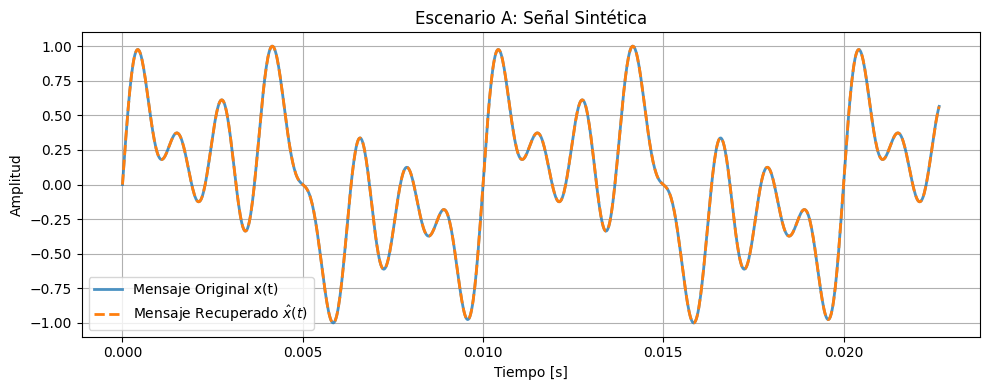

[B] No se encontró el archivo 'audio1.wav'. Asegurate de colocarlo en el directorio.
[C] No se encontró el archivo 'audio2.wav'. Asegurate de colocarlo en el directorio.


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import soundfile as sf
import os

# ==========================================
# a. Función de AM Síncrona (DSB-SC)
# ==========================================
def am_sincrona(x, fs, fc):
    # Vector de tiempo
    t = np.arange(len(x)) / fs
    
    # 1) Generar la señal modulada (Transmisor)
    portadora = np.cos(2 * np.pi * fc * t)
    s_t = x * portadora
    
    # 2) Simular recepción síncrona (Receptor)
    # Multiplicamos la señal recibida nuevamente por el oscilador local
    r_t = s_t * portadora
    
    # 3) Filtro Pasa Bajos de fase cero
    # Frecuencia de Nyquist
    nyq = 0.5 * fs
    
    # Al multiplicar por cos^2(wt), se generan componentes en banda base y en 2*fc.
    # Necesitamos filtrar la componente en 2*fc.
    # Elegimos una frecuencia de corte justo por debajo de la portadora.
    f_corte = fc * 0.8 
    normal_cutoff = f_corte / nyq
    
    # Diseño del filtro Butterworth de orden 5
    b, a = butter(5, normal_cutoff, btype='low', analog=False)
    
    # Aplicamos filtfilt para que sea de fase cero (filtra hacia adelante y hacia atrás)
    x_hat = filtfilt(b, a, r_t)
    
    # Compensación de ganancia: 
    # Matemáticamente, cos^2(a) = 0.5 + 0.5*cos(2a). 
    # El filtro elimina el cos(2a), dejando la señal multiplicada por 0.5.
    x_hat = x_hat * 2.0
    
    return s_t, x_hat

# ==========================================
# Funciones auxiliares para graficar
# ==========================================
def plot_senales(t, x_original, x_recuperada, titulo, muestras=500):
    plt.figure(figsize=(10, 4))
    plt.plot(t[:muestras], x_original[:muestras], label='Mensaje Original x(t)', alpha=0.8, linewidth=2)
    plt.plot(t[:muestras], x_recuperada[:muestras], label='Mensaje Recuperado $\hat{x}(t)$', linestyle='--', linewidth=2)
    plt.title(titulo)
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Amplitud')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ==========================================
# b y c. Escenarios de Prueba
# ==========================================

if __name__ == "__main__":
    # --- ESCENARIO A: Señal Sintética ---
    print("Procesando Escenario A...")
    fs_A = 44100 # Frecuencia de muestreo estándar
    t_A = np.arange(0, 1.0, 1/fs_A) # 1 segundo de simulación
    
    # Suma de 4 senoidales: 100, 300, 500 y 800 Hz
    x_A = (np.sin(2 * np.pi * 100 * t_A) + 
           np.sin(2 * np.pi * 300 * t_A) + 
           np.sin(2 * np.pi * 500 * t_A) + 
           np.sin(2 * np.pi * 800 * t_A))
    x_A = x_A / np.max(np.abs(x_A)) # Normalizamos a rango [-1, 1]
    
    # Elegimos una fc mayor a la máxima frecuencia del mensaje (800 Hz) para evitar aliasing.
    fc_A = 10000 
    
    s_A, x_hat_A = am_sincrona(x_A, fs_A, fc_A)
    plot_senales(t_A, x_A, x_hat_A, 'Escenario A: Señal Sintética', muestras=1000)

    # --- ESCENARIOS B y C: Archivos de Audio ---
    # Nota: Asegurate de tener los archivos "audio1.mp3" y "audio2.mp3" (o .wav) en la misma carpeta.
    # soundfile lee .wav o .flac nativamente. Si tenés estrictamente .mp3, podés usar 'librosa'
    # o convertir los archivos previamente. Asumiremos que tenés archivos legibles por soundfile (.wav).
    
    archivos = {'B': 'audio1.wav', 'C': 'audio2.wav'}
    
    for escenario, archivo in archivos.items():
        if os.path.exists(archivo):
            print(f"Procesando Escenario {escenario} ({archivo})...")
            # Leemos el audio
            x_audio, fs_audio = sf.read(archivo)
            
            # Si el audio es estéreo (2 canales), nos quedamos solo con uno para simplificar
            if len(x_audio.shape) > 1:
                x_audio = x_audio[:, 0]
            
            # El ancho de banda de voz/música puede llegar a 15-20kHz. 
            # fs suele ser 44100 o 48000. 
            # Necesitamos sobremuestrear (resample) si queremos una portadora muy alta, 
            # pero para simular, si fs=44100, podemos usar una fc = 15000 Hz.
            fc_audio = 15000 
            
            # Aplicamos la modulación/demodulación
            s_audio, x_hat_audio = am_sincrona(x_audio, fs_audio, fc_audio)
            
            # Graficamos un segmento (ej: 0.05 segundos)
            t_audio = np.arange(len(x_audio)) / fs_audio
            muestras_plot = int(fs_audio * 0.05)
            plot_senales(t_audio, x_audio, x_hat_audio, f'Escenario {escenario}: {archivo}', muestras=muestras_plot)
            
            # Exportamos el archivo recuperado para comprobar que no se perdió info
            archivo_salida = f"{archivo.split('.')[0]}_recuperado.wav"
            sf.write(archivo_salida, x_hat_audio, fs_audio)
            print(f"Archivo exportado: {archivo_salida}")
        else:
            print(f"[{escenario}] No se encontró el archivo '{archivo}'. Asegurate de colocarlo en el directorio.")

## Ejercicio 6

<>:60: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:82: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:60: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:82: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
C:\Users\fedem\AppData\Local\Temp\ipykernel_16696\96025951.py:60: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
  axs[1].plot(t[:muestras], x_hat_opt[:muestras], label='Recuperada $\hat{x}(t)$', linestyle='--')
C:\Users\fedem\AppData\Local\Temp\ipykernel_16696\96025951.py:82: Syntax

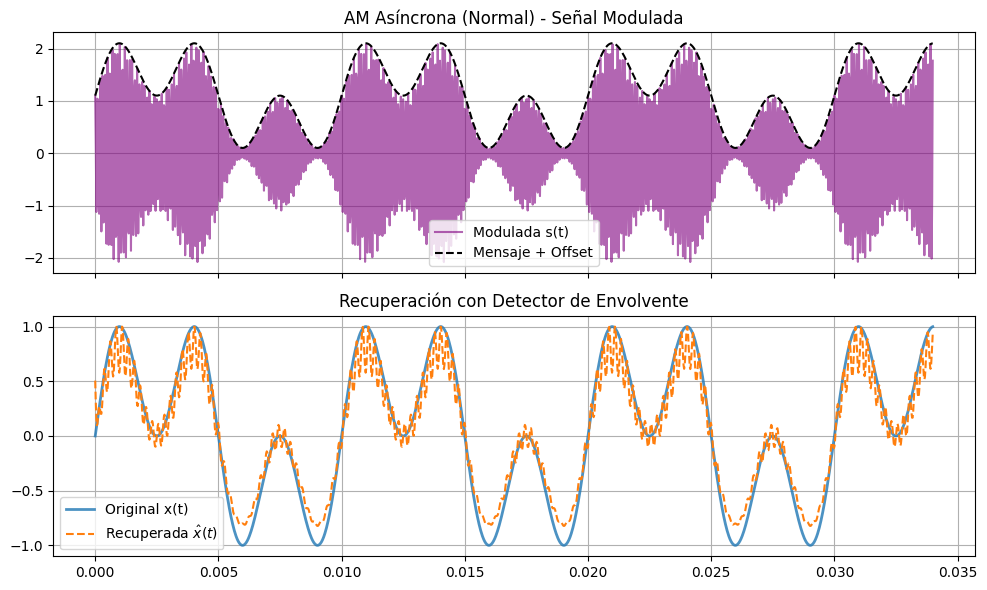

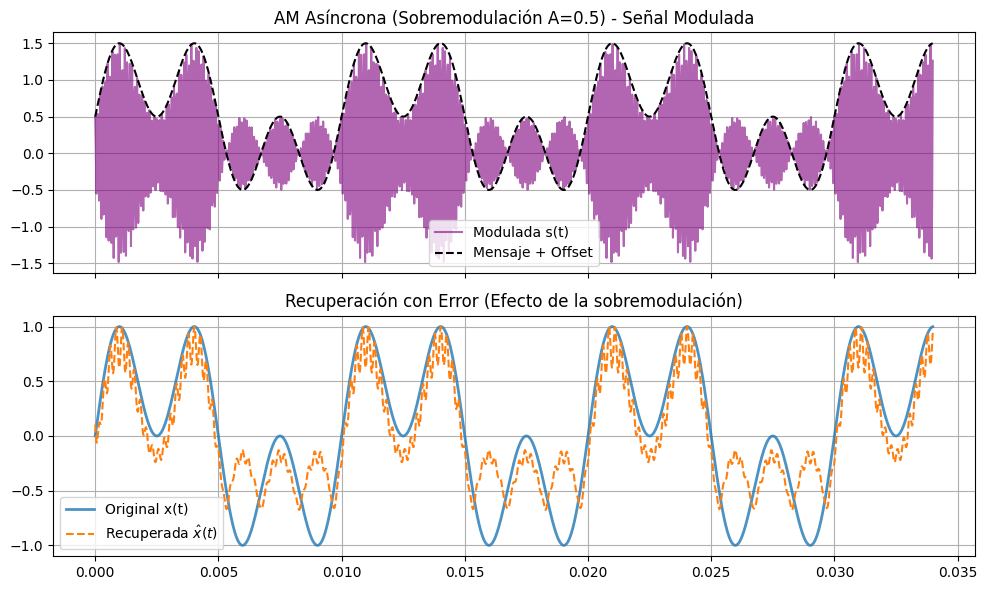

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

def am_asincrona(x, fs, fc, A=None):
    t = np.arange(len(x)) / fs
    
    # --- TRANSMISOR (Modulación) ---
    max_val = np.max(np.abs(x))
    
    # Si no nos pasan un offset 'A', calculamos uno óptimo (10% más grande que el pico máximo)
    if A is None:
        A = max_val * 1.1 
        
    portadora = np.cos(2 * np.pi * fc * t)
    s_t = (A + x) * portadora 
    
    # --- RECEPTOR (Detector de Envolvente) ---
    # 1. Simulación del Diodo
    s_rect = np.abs(s_t)
    
    # 2. Simulación del Capacitor (Filtro Pasa Bajos)
    nyq = 0.5 * fs
    f_corte = fc * 0.5
    b, a = butter(5, f_corte / nyq, btype='low')
    
    x_hat_raw = filtfilt(b, a, s_rect)
    
    # 3. Bloqueo de DC y compensación de ganancia
    x_hat = x_hat_raw - np.mean(x_hat_raw)
    x_hat = x_hat * (np.max(np.abs(x)) / np.max(np.abs(x_hat)))
    
    return s_t, x_hat

# ==========================================
# CONFIGURACIÓN INICIAL DE LA SEÑAL
# ==========================================
fs = 44100
t = np.arange(0, 1.0, 1/fs)
x_synth = np.sin(2 * np.pi * 100 * t) + np.sin(2 * np.pi * 300 * t)
x_synth /= np.max(np.abs(x_synth)) # Normalizamos a [-1, 1]
fc_synth = 10000

# Parámetro visual para hacer zoom en los primeros ciclos
muestras = 1500 

# ==========================================
# PRUEBA 1: AM Normal (A óptimo automático)
# ==========================================
s_opt, x_hat_opt = am_asincrona(x_synth, fs, fc_synth)

fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axs[0].plot(t[:muestras], s_opt[:muestras], color='purple', alpha=0.6, label='Modulada s(t)')
axs[0].plot(t[:muestras], x_synth[:muestras] + np.max(x_synth)*1.1, 'k--', label='Mensaje + Offset')
axs[0].set_title('AM Asíncrona (Normal) - Señal Modulada')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(t[:muestras], x_synth[:muestras], label='Original x(t)', alpha=0.8, linewidth=2)
axs[1].plot(t[:muestras], x_hat_opt[:muestras], label='Recuperada $\hat{x}(t)$', linestyle='--')
axs[1].set_title('Recuperación con Detector de Envolvente')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

# ==========================================
# PRUEBA 2: Sobremodulación (Inciso C: A = 0.5 * max(|x|))
# ==========================================
A_critico = 0.5 * np.max(np.abs(x_synth))
s_crit, x_hat_crit = am_asincrona(x_synth, fs, fc_synth, A=A_critico)

fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axs[0].plot(t[:muestras], s_crit[:muestras], color='purple', alpha=0.6, label='Modulada s(t)')
axs[0].plot(t[:muestras], x_synth[:muestras] + A_critico, 'k--', label='Mensaje + Offset')
axs[0].set_title('AM Asíncrona (Sobremodulación A=0.5) - Señal Modulada')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(t[:muestras], x_synth[:muestras], label='Original x(t)', alpha=0.8, linewidth=2)
axs[1].plot(t[:muestras], x_hat_crit[:muestras], label='Recuperada $\hat{x}(t)$', linestyle='--')
axs[1].set_title('Recuperación con Error (Efecto de la sobremodulación)')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

## Ejercicio 7

--- Análisis de Potencia Promedio (Normalizada) ---
Potencia Portadora sin modular: 0.5000 W
Potencia Señal FM (Caso A - Senoidal): 0.5000 W
Potencia Señal FM (Caso B - Cuadrada): 0.5000 W


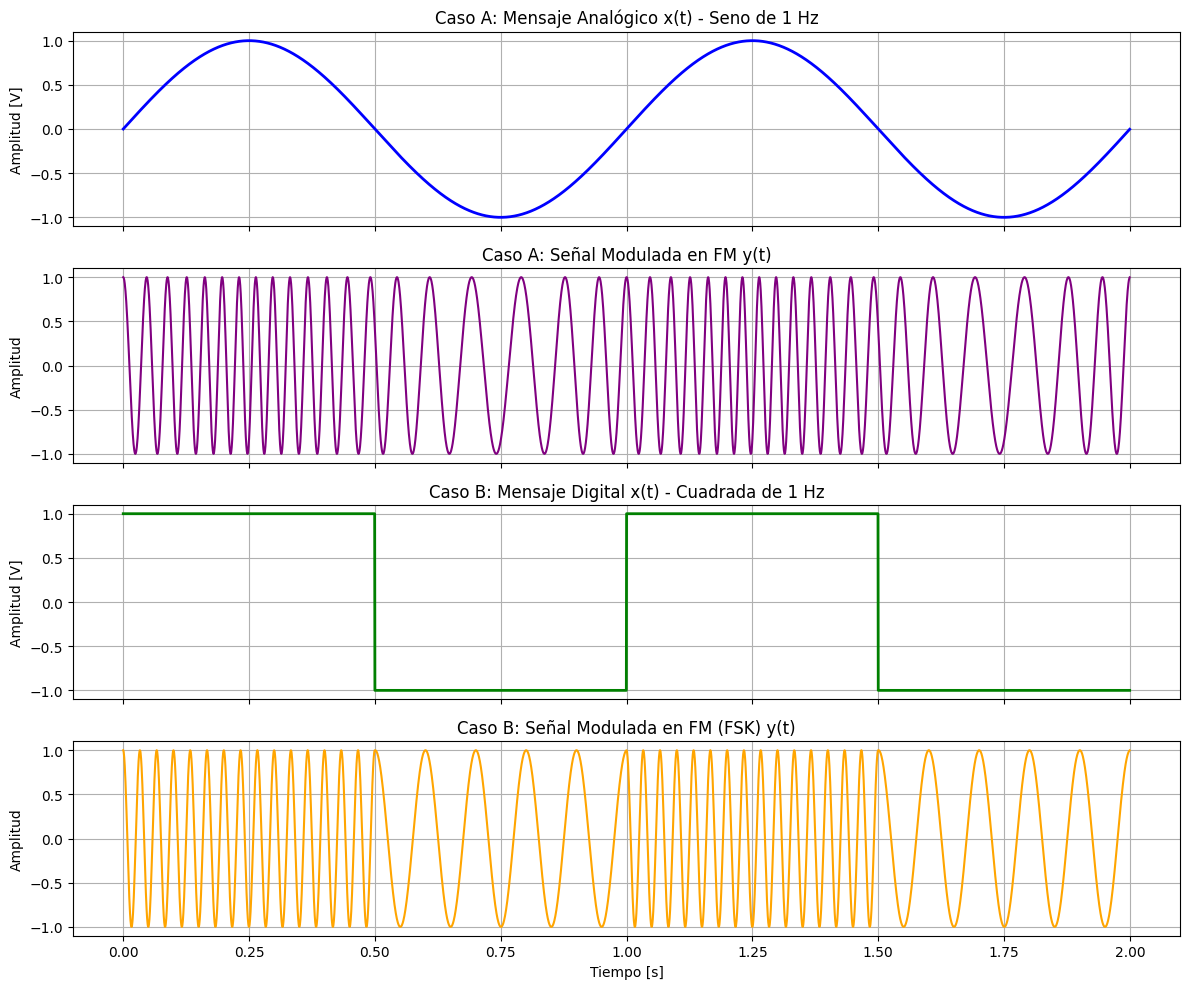

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import square

# ==========================================
# a. Función de Modulación FM
# ==========================================
def modulacion_fm(x, fs, fc, kf):
    # Vector de tiempo discreto
    t = np.arange(len(x)) / fs
    
    # El paso de tiempo discreto dt = 1/fs
    dt = 1 / fs
    
    # Aproximación discreta de la integral usando la suma acumulativa
    integral_x = np.cumsum(x) * dt
    
    # Ecuación de la señal FM: y(t) = cos(2*pi*fc*t + 2*pi*kf * integral(x(t)))
    y = np.cos(2 * np.pi * fc * t + 2 * np.pi * kf * integral_x)
    
    return y

# ==========================================
# b y c. Configuración de parámetros y señales
# ==========================================
fs = 2000      # Frecuencia de muestreo (Hz)
fc = 20        # Frecuencia de la portadora (Hz)
kf = 10        # Desviación de frecuencia (Hz/V)
duracion = 2   # 2 segundos de transmisión
t = np.arange(0, duracion, 1/fs)

# Señal Analógica (Caso A): Senoidal de 1 Hz y 1 V
x_A = np.sin(2 * np.pi * 1 * t)

# Señal Digital FSK (Caso B): Cuadrada de 1 Hz entre +1 V y -1 V
x_B = square(2 * np.pi * 1 * t)

# Aplicamos la modulación FM
y_A = modulacion_fm(x_A, fs, fc, kf)
y_B = modulacion_fm(x_B, fs, fc, kf)

# ==========================================
# e. Análisis de Potencia (Lo calculamos antes de graficar)
# ==========================================
# Portadora pura (sin modular)
portadora_pura = np.cos(2 * np.pi * fc * t)

# Cálculo de potencia: P = (1/N) * sum(señal^2)
P_portadora = np.mean(portadora_pura**2)
P_A = np.mean(y_A**2)
P_B = np.mean(y_B**2)

print("--- Análisis de Potencia Promedio (Normalizada) ---")
print(f"Potencia Portadora sin modular: {P_portadora:.4f} W")
print(f"Potencia Señal FM (Caso A - Senoidal): {P_A:.4f} W")
print(f"Potencia Señal FM (Caso B - Cuadrada): {P_B:.4f} W")

# ==========================================
# d. Gráficos en Subplots
# ==========================================
fig, axs = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

# Caso A: Mensaje original
axs[0].plot(t, x_A, color='blue', linewidth=2)
axs[0].set_title('Caso A: Mensaje Analógico x(t) - Seno de 1 Hz')
axs[0].set_ylabel('Amplitud [V]')
axs[0].grid(True)

# Caso A: Señal FM Modulada
axs[1].plot(t, y_A, color='purple')
axs[1].set_title('Caso A: Señal Modulada en FM y(t)')
axs[1].set_ylabel('Amplitud')
axs[1].grid(True)

# Caso B: Mensaje original (Digital/FSK)
axs[2].plot(t, x_B, color='green', linewidth=2)
axs[2].set_title('Caso B: Mensaje Digital x(t) - Cuadrada de 1 Hz')
axs[2].set_ylabel('Amplitud [V]')
axs[2].grid(True)

# Caso B: Señal FM Modulada
axs[3].plot(t, y_B, color='orange')
axs[3].set_title('Caso B: Señal Modulada en FM (FSK) y(t)')
axs[3].set_xlabel('Tiempo [s]')
axs[3].set_ylabel('Amplitud')
axs[3].grid(True)

plt.tight_layout()
plt.show()